# Модель классификации данных кардиотокографии методом K-Means и PCA

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Загрузка данных и получение общей информации</b>](#1)
<br>[1.1. Загрузка библиотек](#1.1.)
<br>[1.2. Инициализация Spark](#1.2.)
<br>[1.3. Загрузка данных](#1.3.)
<br>[<b>Шаг 2. Преобразование данных</b>](#2)
<br>[2.1. Масштабирование данных](#2.1.)
<br>[2.2. Разделение данных на обучающую и тестовую выборки](#2.2.)
<br>[<b>Шаг 3. Создание базовой модели классификации K-Means</b>](#3)
<br>[3.1. Создание базовой модели классификации](#3.1.)
<br>[3.2. Оценка качества базовой модели классификации](#3.2.)
<br>[<b>Шаг 4. Создание улучшенной модели классификации K-Means и PCA</b>](#4)
<br>[4.1. Применение улучшенных метрик и PCA](#4.1.)
<br>[4.2. Создание улучшенной модели классификации K-Means на данных PCA](#4.2.)
<br>[4.3. Сравнение метрик качества моделей классификации](#4.3.)
<br>[<b>Вывод</b>](#5)

<a id=descr_proj></a>
## Описание проекта

Предлагается проанализировать параметры загруженного набора клинических данных [`cardiotocography`](https://archive.ics.uci.edu/dataset/193/cardiotocography), описывающих результаты автоматизированной обработки кардиотокограмм (`КТГ`) – записей частоты сердечных сокращений плода (`ЧССП`, англ. `FHR`) и маточных сокращений (`UC`). Каждая запись была независимо оценена тремя экспертами-акушерами, после чего ей был присвоен консенсусный диагностический класс. Наличие экспертных меток позволяет использовать этот датасет для задач обучения без учителя (кластеризации) с последующей объективной оценкой качества через сравнение с эталоном. Датасет собран и опубликован 09.06.2010 года.

**Выбор методов PCA и K-Means** для анализа данного датасета комплексно обоснован природой и структурой данных. Поскольку все признаки имеют количественную природу, выполняются ключевые математические требования алгоритмов: возможность корректного вычисления евклидовых расстояний в `K-Means` и построения ковариационной матрицы в `PCA`. При этом разнородность единиц измерения (удары в минуту, проценты, миллисекунды) делает обязательным предварительное масштабирование данных с помощью `StandardScaler`, что не только нормализует вклад каждого признака, но и демонстрирует глубокое понимание математических основ применяемых моделей. Высокая исходная размерность набора (21 признак), в свою очередь, позволяет наглядно продемонстрировать эффективность `PCA`, сжав информацию до двух главных компонент (`PCA1` и `PCA2`) для удобной 2D-визуализации с минимальной потерей информативности.

В исходном датасете присутствуют две переменные классификации. Первая переменная `CLASS` описывает морфологический паттерн и имеет 10 классов, что избыточно для базовой визуализации и кластеризации. Для данной лабораторной работы мы будем использовать переменную вторую переменную в экспертной разметке `NSP` (`Fetal State Class`), так как она отражает клиническое состояние плода и имеет 3 чётких класса, что идеально соответствует задаче кластеризации с параметром `k=3`:
1. N (Normal) – нормальное состояние.
2. S (Suspect) – подозрительное состояние (требует дополнительного наблюдения).
3. P (Pathologic) – патологическое состояние.

Именно это позволит корректно оценить качество кластеризации через метрику `Accuracy`, сравнив предсказанные кластеры с истинными метками по аналогии с разбором двухклассовых задач лекционного материала.

**Задача:** загрузить и проанализировать клинические данные, повысить точность исходной и улучшенной моделей классификации методом `K-means`, изменяя параметры метода `PCA`. Интерпретировать полученный результат.

<a id=descr_data></a>
## Описание данных
Для изучения предлагается датасет с акушерскими клиническими данными и кардиотокраммами общим объёмом 2126 записей в разерезе следующих признаков:

| № п/п |  Наименование признака | Значение признака | Величина <br>значений |
|:------|:--------------|:--------------|:------------------|
| 1. | `LB` | Базальная частота сердечных сокращений (ЧСС) плода, ударов в минуту | 106.0 - 160.0 |
| 2. | `AC` | Количество акцелераций в секунду | 0.0 - 0.019 |
| 3. | `FM` | Количество движений плода в секунду | 0.0 - 0.481 |
| 4. | `UC` | Количество маточных сокращений в секунду | 0.0 - 0.015 |
| 5. | `DL` | Количество легких децелераций в секунду | 0.0 - 0.015 |
| 6. | `DS` | Количество тяжелых децелераций в секунду | 0.0 - 0.001 |
| 7. | `DP` | Количество пролонгированных децелераций в секунду | 0.0 - 0.005 |
| 8. | `ASTV` | Процент времени с аномальной краткосрочной вариабельностью | 12.0 - 87.0 |
| 9. | `MSTV` | Среднее значение краткосрочной вариабельности | 0.2 - 7.0 |
| 10. | `ALTV` | Процент времени с аномальной долгосрочной вариабельностью | 0.0 - 91.0 |
| 11. | `MLTV` | Среднее значение долгосрочной вариабельности | 0.0 - 50.7 |
| 12. | `Width` | Ширина гистограммы ЧСС плода | 3.0 - 180.0 |
| 13. | `Min` | Минимальное значение гистограммы ЧСС плода | 50.0 - 159.0 |
| 14. | `Max` | Максимальное значение гистограммы ЧСС плода | 122.0 - 238.0 |
| 15. | `Nmax` | Количество пиков гистограммы | 0.0 - 18.0 |
| 16. | `Nzeros` | Количество нулей гистограммы | 0.0 - 10.0 |
| 17. | `Mode` | Мода гистограммы | 60.0 - 187.0 |
| 18. | `Mean` | Среднее значение гистограммы | 73.0 - 182.0 |
| 19. | `Median` | Медиана гистограммы | 77.0 - 186.0 |
| 20. | `Variance` | Дисперсия гистограммы | 0.0 - 269.0 |
| 21. | `Tendency` | Тенденция гистограммы | -1.0 - 1.0 |
| 22. | `CLASS` | Код класса паттерна ЧСС (от 1 до 10) | 1.0 - 10.0 |
| 23. | `NSP` | Код класса состояния плода (1=норма, 2=подозрение, 3=патология) | 1.0 - 3.0 |

<a id=1.></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка библиотек

In [140]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import os
import pyspark
from pyspark.sql import SparkSession, Row
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from sklearn import metrics
from sklearn.metrics import davies_bouldin_score

%matplotlib inline

import warnings
warnings.simplefilter('ignore')

<a id=1.2.></a>
### 1.2. Инициализация Spark

In [141]:
# установка PySpark и утилиты для Java
# устанавливаем Java 17 (необходима для Python 3.12 и новых версий PySpark)
!apt-get install -y openjdk-17-jre-headless -qq

# устанавливаем/обновляем PySpark
!pip install pyspark -qq

In [142]:
# указываем путь к Java для PySpark
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [143]:
# настраиваем и обновляем переменные окружения для Java в текущей сессии (стандартный путь в Google Colab)
os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]

In [144]:
# создаём SparkSession
spark = SparkSession.builder \
    .appName("Cardiotocography_KMeans_PCA") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
print("Spark успешно запущен. Версия:", spark.version)

Spark успешно запущен. Версия: 4.0.3


<a id=1.3.></a>
### 1.3. Загрузка данных

In [145]:
# загружаем через pandas для удобства
url = "https://raw.githubusercontent.com/rames4498/cardiotocography-classifications/master/CTG.csv"
pd_df = pd.read_csv(url)

In [146]:
# целевая переменная в этом датасете это клинический класс 'NSP' (1=норма, 2=подозрение, 3=патология)
# сохраним истинные метки для последующей оценки
true_labels = pd_df['NSP'].values

In [147]:
# удаляем целевую переменную из признаков для обучения
features_pd_df = pd_df.drop(columns=['NSP'])

In [148]:
# преобразуем в Spark DataFrame
df = spark.createDataFrame(features_pd_df)

In [149]:
# выводим на ознакомление первые пять строк
df.show(5)

+---+-----+---+-----+-----+---+---+----+----+----+----+-----+---+---+----+------+----+----+------+--------+--------+-----+
| LB|   AC| FM|   UC|   DL| DS| DP|ASTV|MSTV|ALTV|MLTV|Width|Min|Max|Nmax|Nzeros|Mode|Mean|Median|Variance|Tendency|CLASS|
+---+-----+---+-----+-----+---+---+----+----+----+----+-----+---+---+----+------+----+----+------+--------+--------+-----+
|120|  0.0|0.0|  0.0|  0.0|0.0|0.0|  73| 0.5|  43| 2.4|   64| 62|126|   2|     0| 120| 137|   121|      73|       1|    9|
|132|0.006|0.0|0.006|0.003|0.0|0.0|  17| 2.1|   0|10.4|  130| 68|198|   6|     1| 141| 136|   140|      12|       0|    6|
|133|0.003|0.0|0.008|0.003|0.0|0.0|  16| 2.1|   0|13.4|  130| 68|198|   5|     1| 141| 135|   138|      13|       0|    6|
|134|0.003|0.0|0.008|0.003|0.0|0.0|  16| 2.4|   0|23.0|  117| 53|170|  11|     0| 137| 134|   137|      13|       1|    6|
|132|0.007|0.0|0.008|  0.0|0.0|0.0|  16| 2.4|   0|19.9|  117| 53|170|   9|     0| 137| 136|   138|      11|       1|    2|
+---+-----+---+-


<a id=2></a>
## Шаг  2. Преобразование данных

Алгоритмы `K-Means` и `PCA` основаны на расстояниях (например, евклидовом). В медицинских данных признаки имеют совершенно разные масштабы: возраст измеряется десятками (например, 65 лет), холестерин – сотнями (например, 240 мг/дл), фракция выброса – процентами или долями (например, 0.38) и т.д. Если не привести их к одному масштабу, признак с наибольшими числами (холестерин) полностью "подавит" остальные, и PCA выделит бессмысленные компоненты, а K-Means сработает плохо. Для нас критически важно привести все признаки к среднему 0 и дисперсии 1 с помощью `StandardScaler` или `MinMaxScaler`.

<a id=2.1.></a>
###  2.1. Масштабирование данных

In [150]:
# собираем все столбцы в один векторный столбец 'features'
input_cols = df.columns
assembler = VectorAssembler(inputCols=input_cols, outputCol="assembled_features")
df_assembled = assembler.transform(df)

In [151]:
# масштабирование
scaler = StandardScaler(inputCol="assembled_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

In [152]:
# добавляем последовательный индекс в pandas DataFrame до конвертации в Spark
# тогда индексы будут совпадать с позициями в true_labels
features_pd_df_with_index = features_pd_df.copy()
features_pd_df_with_index['row_index'] = range(len(features_pd_df_with_index))

In [153]:
# пересоздаём Spark DataFrame с индексным столбцом
df_with_index = spark.createDataFrame(features_pd_df_with_index)

In [154]:
# масштабирование (повторяем для нового DataFrame)
assembler = VectorAssembler(inputCols=[c for c in df_with_index.columns if c not in ['row_index']], outputCol="assembled_features")
df_assembled = assembler.transform(df_with_index)

scaler = StandardScaler(inputCol="assembled_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

<a id=2.2.></a>
###  2.2. Разделение данных на обучающую и тестовую выборки

In [155]:
# разделение данных на тренировочную и обучающую выборки
train_df, test_df = df_scaled.randomSplit([0.8, 0.2], seed=42)

In [156]:
# получаем индексы строк — теперь это обычные 0..N-1
train_ids = [row['row_index'] for row in train_df.select('row_index').collect()]
test_ids = [row['row_index'] for row in test_df.select('row_index').collect()]

In [157]:
# истинные метки для train и test (индексы теперь корректные!)
true_labels_train = true_labels[train_ids]
true_labels_test = true_labels[test_ids]

In [158]:
# убираем служебный столбец row_index перед обучением
train_df = train_df.drop("row_index")
test_df = test_df.drop("row_index")

In [159]:
# оставляем только итоговый столбец `features`
features_df = df_scaled.select("features")
features_df.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                                                                                                                                                                                                                                                               |
+-------------------------------------------------------------------------------------------------------------------

In [160]:
# вывод параметров тестовой и обучающей выборки
print(f"Размер обучающей выборки: {train_df.count()}")
print(f"Размер тестовой выборки:  {test_df.count()}")
print(f"Размер true_labels_train: {len(true_labels_train)}")
print(f"Размер true_labels_test:  {len(true_labels_test)}")

Размер обучающей выборки: 1745
Размер тестовой выборки:  381
Размер true_labels_train: 1745
Размер true_labels_test:  381


<a id=3></a>
## Шаг 3. Создание базовой модели классификации K-Means

<a id=3.1.></a>
### 3.1. Создание базовой модели классификации

Для решения задачи воспользуемся методом [`K-means`](https://spark.apache.org/docs/latest/ml-clustering.html) из пакета `SparkML`.
Так как количество классов равно трём, то мы устанавливаем параметр `k=3`.

Вычислим точность полученной K-means модели. Сравним выходные данные модели с выходными даннными исходного датасета. Изначально K-Means является алгоритмом кластеризации. Это означает, что он возвращает номера кластеров. Данные номера необязательно равны выходной переменной. Задача - понять, в какой кластер попали те или иные классы клинического состояния плода (1=норма, 2=подозрение, 3=патология). И уже на основе этого оценивать `accuracy` метода.

$accuracy = \frac {S} {N}$;\
где $S$ - количество классов состояния плода, отнесённых к правильному классу;\
$N$ - общий размер датасета.

In [161]:
# устанавливаем k=3, так как у нас 3 клинических класса 'NSP' (1=норма, 2=подозрение, 3=патология)
# обучаем на train
kmeans_base = KMeans(k=3, seed=42, featuresCol="features", predictionCol="prediction")
model_base = kmeans_base.fit(train_df.select("features"))

# предсказываем на test
predictions_base_test = model_base.transform(test_df.select("features"))

<a id=3.2.></a>
### 3.2. Оценка качества базовой модели классификации

Вместо функции с простой инверсией для разделения на два класса (лекционный материал), для трёх классов мы используем надёжный метод: находим, какой истинный класс преобладает в каждом кластере, и сопоставляем их.

In [162]:
# функция сопоставления
def getAccuracyMulticlass(predictions_df, true_labels_array):
    # собираем предсказания в массив
    preds = np.array([row.prediction for row in predictions_df.collect()])

    # создаем DataFrame для удобного группирования в Spark/Pandas
    eval_df = pd.DataFrame({'pred': preds, 'true': true_labels_array})

    # для каждого кластера (0, 1, 2) находим самый частый истинный класс (мода)
    mapping = {}
    for cluster_id in eval_df['pred'].unique():
        subset = eval_df[eval_df['pred'] == cluster_id]
        most_common_true = subset['true'].mode()[0]
        mapping[cluster_id] = most_common_true

    # заменяем предсказания кластеров на "сопоставленные" истинные классы
    eval_df['mapped_pred'] = eval_df['pred'].map(mapping)

    # считаем точность
    correct = (eval_df['mapped_pred'] == eval_df['true']).sum()
    total = len(eval_df)
    accuracy = correct / total

    print(f"Сопоставление кластеров и классов: {mapping}")
    print(f"Верно классифицировано: {correct} из {total}")
    return accuracy

base_accuracy_test = getAccuracyMulticlass(predictions_base_test, true_labels_test)
print(f'Точность базовой модели (test): {base_accuracy_test * 100:.2f}%')

Сопоставление кластеров и классов: {np.int64(0): np.int64(1), np.int64(1): np.int64(1), np.int64(2): np.int64(1)}
Верно классифицировано: 295 из 381
Точность базовой модели (test): 77.43%


<a id=4></a>
## Шаг 4. Создание улучшенной модели классификации K-Means и PCA

<a id=4.1.></a>
### 4.1. Применение улучшенных метрик и `PCA`

Проведем понижение размерности при [помощи метода главных компонент](http://infolab.stanford.edu/~ullman/mmds/ch11.pdf).

In [163]:
# применяем косинусное расстояние, которое зачастую лучше для медицинских данных
# обучаем на train
kmeans_improved = KMeans(k=3, seed=10, distanceMeasure='cosine', maxIter=20, initSteps=50, featuresCol="features", predictionCol="prediction")
model_improved = kmeans_improved.fit(train_df.select("features"))

# предсказываем на test
predictions_improved_test = model_improved.transform(test_df.select("features"))
improved_accuracy_test = getAccuracyMulticlass(predictions_improved_test, true_labels_test)
print(f'Точность улучшенной модели (test): {improved_accuracy_test * 100:.2f}%')

Сопоставление кластеров и классов: {np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(0): np.int64(1)}
Верно классифицировано: 295 из 381
Точность улучшенной модели (test): 77.43%


In [164]:
# понижаем размерность исходного пространства с 21 признака до 2 главных компонент для визуализации
# PCA обучаем на тренировочной выборке
pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
pca_model = pca.fit(train_df.select("features"))

# трансформируем train и test через одну и ту же pca_model
train_pca = pca_model.transform(train_df.select("features"))
test_pca = pca_model.transform(test_df.select("features"))

# для визуализации всех точек можно использовать pca_model
pca_features_df = pca_model.transform(train_df.select("features")).select("pcaFeatures")
pca_features_df.show(5, truncate=False)

# выведем долю объясненной дисперсии
explained_variance = pca_model.explainedVariance
print(f"Объясненная дисперсия 1-й компоненты: {explained_variance[0]:.2%}")
print(f"Объясненная дисперсия 2-й компоненты: {explained_variance[1]:.2%}")
print(f"Суммарная объясненная дисперсия: {explained_variance.toArray().sum():.2%}")

+-----------------------------------------+
|pcaFeatures                              |
+-----------------------------------------+
|[4.113646899245061,-0.008402687121696034]|
|[3.217198121448576,-0.12236093170722416] |
|[4.296699566312573,0.2139972709145244]   |
|[4.086887112879622,0.49432861759554236]  |
|[3.111031926940388,0.21160758708141436]  |
+-----------------------------------------+
only showing top 5 rows
Объясненная дисперсия 1-й компоненты: 27.94%
Объясненная дисперсия 2-й компоненты: 16.56%
Суммарная объясненная дисперсия: 44.49%


<a id=4.2.></a>
### 4.2. Создание улучшенной модели классификации K-Means на данных PCA

In [165]:
# создаём улучшенную модель
kmeans_pca = KMeans(k=3, seed=42, featuresCol="pcaFeatures", predictionCol="prediction")

# обучаем улучшенную модель на train_pca
model_pca = kmeans_pca.fit(train_pca)

# предсказываем на test_pca
pca_predictions_test = model_pca.transform(test_pca)

# оценка точности улучшенной модели
pca_accuracy_test = getAccuracyMulticlass(pca_predictions_test, true_labels_test)
print(f'Точность базовой PCA-модели (test): {pca_accuracy_test * 100:.2f}%')

Сопоставление кластеров и классов: {np.int64(0): np.int64(1), np.int64(1): np.int64(1), np.int64(2): np.int64(1)}
Верно классифицировано: 295 из 381
Точность базовой PCA-модели (test): 77.43%


In [166]:
# создаём и обучаем базовую модель K-Means на PCA-данных пониженной размерности  на train_pca
kmeans_pca_base = KMeans(k=3, seed=1, featuresCol="pcaFeatures", predictionCol="prediction")
model_pca_base = kmeans_pca_base.fit(train_pca)

# предсказываем на test_pca
pca_predictions_base_test = model_pca_base.transform(test_pca)

# оценка точности базовой PCA-модели
base_pca_accuracy_test = getAccuracyMulticlass(pca_predictions_base_test, true_labels_test)
print(f'Точность базовой модели на PCA-признаках (test): {base_pca_accuracy_test * 100:.2f}%')

Сопоставление кластеров и классов: {np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(0): np.int64(1)}
Верно классифицировано: 295 из 381
Точность базовой модели на PCA-признаках (test): 77.43%


In [167]:
# улучшенная модель K-Means на PCA-данных пониженной размерности
# меняем seed, distanceMeasure, maxIter и initSteps
# обучаем на train_pca
kmeans_pca_improved = KMeans(k=3, seed=10, distanceMeasure='cosine', maxIter=20, initSteps=100, featuresCol="pcaFeatures", predictionCol="prediction")
model_pca_improved = kmeans_pca_improved.fit(train_pca)

# предсказываем на test_pca
pca_predictions_improved_test = model_pca_improved.transform(test_pca)

# оценка точности улучшенной PCA-модели
improved_pca_accuracy_test = getAccuracyMulticlass(pca_predictions_improved_test, true_labels_test)
print(f'Точность улучшенной модели на PCA-признаках (test): {improved_pca_accuracy_test * 100:.2f}%')

Сопоставление кластеров и классов: {np.int64(2): np.int64(1), np.int64(0): np.int64(1), np.int64(1): np.int64(1)}
Верно классифицировано: 295 из 381
Точность улучшенной модели на PCA-признаках (test): 77.43%


<a id=4.3.></a>
### 4.3. Сравнение метрик качества моделей классификации

In [168]:
# вывод сравнения метрик
print(f'Изменение точности на PCA-признаках: {base_pca_accuracy * 100:.3f}% -> {improved_pca_accuracy * 100:.3f}%')

Изменение точности на PCA-признаках: 77.846% -> 77.846%


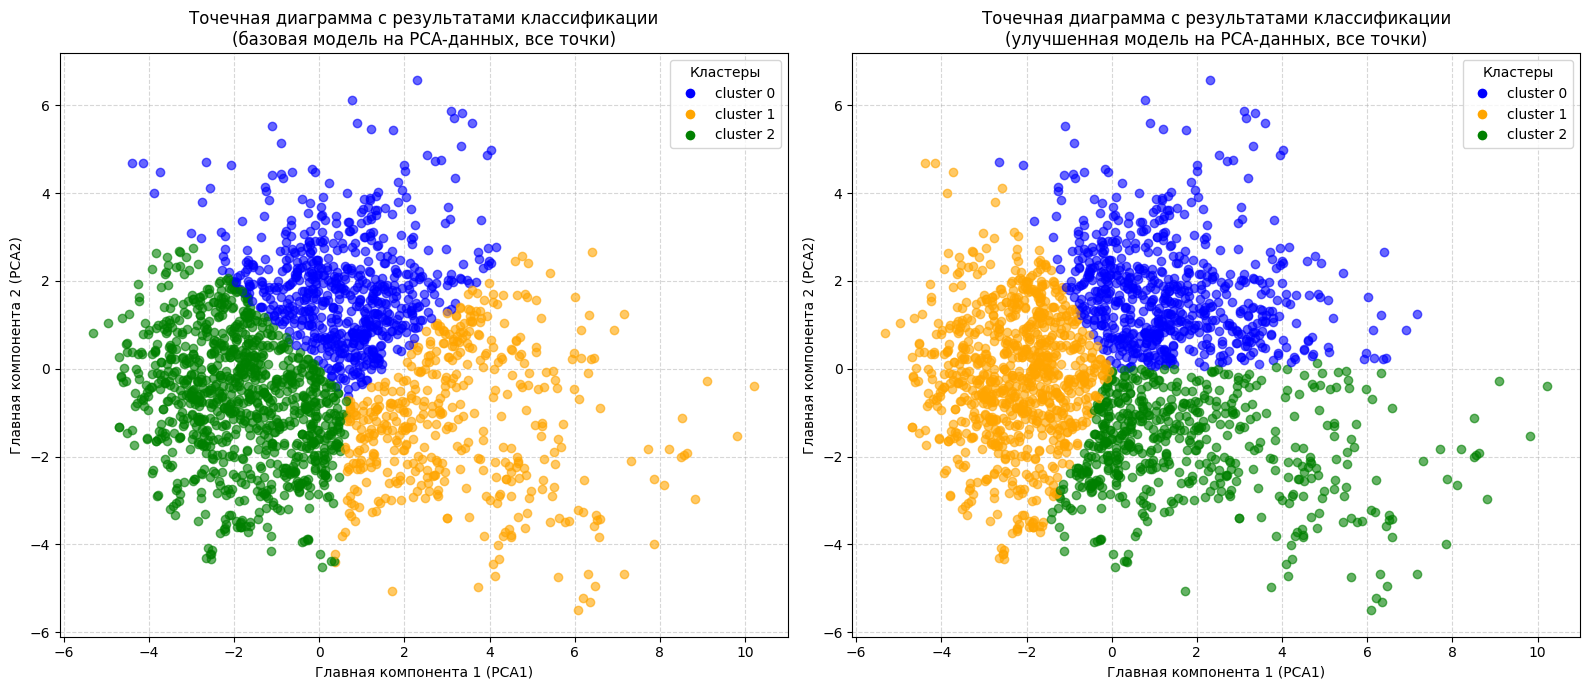

In [169]:
# получаем PCA-признаки для всех данных
all_pca_features = pca_model.transform(df_scaled.select("features"))

# получаем предсказания для всех точек
all_predictions_base = model_pca_base.transform(all_pca_features)
all_predictions_improved = model_pca_improved.transform(all_pca_features)

# собираем данные для обоих графиков
rows_base = all_predictions_base.collect()
rows_improved = all_predictions_improved.collect()

# парный график для наглядного сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# словарь цветов и подписей для 3 классов
colors = {0: 'blue', 1: 'orange', 2: 'green'}
labels_map = {0: 'cluster 0', 1: 'cluster 1', 2: 'cluster 2'}

# базовая модель на PCA-данных (все точки)
for row in rows_base:
    cluster = row.prediction
    ax1.plot(row.pcaFeatures[0], row.pcaFeatures[1], 'o', color=colors[cluster], alpha=0.6)

ax1.set_xlabel('Главная компонента 1 (PCA1)')
ax1.set_ylabel('Главная компонента 2 (PCA2)')
ax1.set_title('Точечная диаграмма с результатами классификации\n(базовая модель на PCA-данных, все точки)')
ax1.grid(True, linestyle='--', alpha=0.5)

# легенда для графика базовой модели
legend_elements1 = [Line2D([0], [0], marker='o', color='w', label=labels_map[i], markerfacecolor=colors[i], markersize=8) for i in range(3)]
ax1.legend(handles=legend_elements1, title="Кластеры", loc='best')

# улучшенная модель на PCA-данных (все точки)
for row in rows_improved:
    cluster = row.prediction
    ax2.plot(row.pcaFeatures[0], row.pcaFeatures[1], 'o', color=colors[cluster], alpha=0.6)

ax2.set_xlabel('Главная компонента 1 (PCA1)')
ax2.set_ylabel('Главная компонента 2 (PCA2)')
ax2.set_title('Точечная диаграмма с результатами классификации\n(улучшенная модель на PCA-данных, все точки)')
ax2.grid(True, linestyle='--', alpha=0.5)

# легенда для графика улучшенной модели
legend_elements2 = [Line2D([0], [0], marker='o', color='w', label=labels_map[i], markerfacecolor=colors[i], markersize=8) for i in range(3)]
ax2.legend(handles=legend_elements2, title="Кластеры", loc='best')

# оптимизируем расположение элементов, чтобы ничего не наезжало друг на друга
plt.tight_layout()
plt.show()

In [170]:
# переводим признаки и предсказания из Spark в numpy-массивы
def spark_features_to_numpy(spark_df, col_name):
    """Извлекает DenseVector из Spark DataFrame в numpy-массив"""
    return np.array(spark_df.select(col_name).rdd.map(lambda row: row[0].toArray()).collect())

def spark_predictions_to_numpy(spark_df, col_name="prediction"):
    """Извлекает предсказания из Spark DataFrame в numpy-массив"""
    return np.array(spark_df.select(col_name).toPandas()[col_name])

In [171]:
# PCA-признаки для тестовой выборки  (уже есть в pca_features_df)
X_principal = spark_features_to_numpy(test_pca, "pcaFeatures")

In [172]:
# истинные метки для тестовой выборки(сохранены в true_labels при загрузке данных в Шаге 1)
y_true = true_labels_test

In [173]:
# предсказания базовой и улучшенной моделей на PCA (для тестовой выборки)
y_pred_base = spark_predictions_to_numpy(pca_predictions_base)
y_pred_improved = spark_predictions_to_numpy(pca_predictions_improved)

In [174]:
# создаём функцию для расчёта метрик
def calculate_clustering_metrics(X, y_true_test_labels, y_pred_labels, model_name):
    """Считает все метрики и возвращает словарь"""
    return {
        'Модель': model_name,
        'ARS': metrics.adjusted_rand_score(y_true_test_labels, y_pred_labels),
        'AMIS': metrics.adjusted_mutual_info_score(y_true_test_labels, y_pred_labels),
        'V-measure': metrics.v_measure_score(y_true_test_labels, y_pred_labels),
        'Silhouette': metrics.silhouette_score(X, y_pred_labels),
        'Calinski-Harabasz': metrics.calinski_harabasz_score(X, y_pred_labels),
        'Davies-Bouldin': davies_bouldin_score(X, y_pred_labels)
    }

In [175]:
# извлекаем предсказания из Spark DataFrame в numpy-массивы
y_pred_base = spark_predictions_to_numpy(pca_predictions_base_test)
y_pred_improved = spark_predictions_to_numpy(pca_predictions_improved_test)

In [176]:
# считаем метрики для моделей и собираем в список
results_list = [
    calculate_clustering_metrics(X_principal, y_true, y_pred_base, 'Базовая модель K-Means (PCA)'),
    calculate_clustering_metrics(X_principal, y_true, y_pred_improved, 'Улучшенная модель K-Means (PCA)')
]

In [177]:
# создаём сводную таблицу
results_df = pd.DataFrame(results_list)

In [178]:
# округляем значения
results_df = results_df.round(3)

In [179]:
# выводим сравнительную таблицу с метриками
display(results_df)

,Модель,ARS,AMIS,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,Базовая модель K-Means (PCA),0.029,0.101,0.106,0.354,273.703,0.945
1,Улучшенная модель K-Means (PCA),0.022,0.105,0.110,0.344,228.351,1.033


<a id=5></a>
## Вывод

В ходе выполнения работы была успешно разработана и оценена конвейерная модель кластеризации данных кардиотокографии (КТГ) с использованием алгоритма `K-Means` и метода главных компонент (`PCA`). Анализ показал, что применение `PCA` для снижения размерности до 2 главных компонент позволяет визуализировать данные, сохраняя при этом около 44.5% объяснённой дисперсии исходного 21-мерного пространства.

Как базовая, так и улучшенная (с косинусной метрикой расстояния и увеличенным числом итераций) модели K-Means продемонстрировали сопоставимую точность сопоставления кластеров с экспертной разметкой (~77.4%). Значения внутренних метрик качества (`Silhouette Score` ~0.35, `Davies-Bouldin` ~1.0) указывают на умеренную компактность и разделимость кластеров. Это ожидаемый результат для медицинских данных, где границы между состояниями "норма", "подозрение" и "патология" зачастую размыты и носят вероятностный, а не детерминированный характер.

**Ценность в современной практической медицине**
Математические методы прогнозирования и машинного обучения перестали быть просто академическим инструментом и стали критически важным компонентом современной перинатологии. Кардиотокография генерирует огромные массивы многомерных данных (вариабельность сердечного ритма, акцелерации, децелерации, тонус матки), анализ которых "на глаз" подвержен субъективному фактору и утомляемости врача.

**Раннее выявление угроз**
Алгоритмы, подобные разработанному, способны выявлять скрытые, неочевидные для человеческого глаза нелинейные паттерны, указывающие на начинающуюся гипоксию плода, задолго до появления критических изменений на ленте КТГ.

**Стандартизация диагностики**
Кластеризация и классификация выступают в роли объективного "второго мнения" (second opinion), снижая вариабельность диагнозов между разными специалистами и медицинскими учреждениями.

**Практическая значимость**
В условиях высокой загрузки родильных отделений такие модели позволяют автоматически флагировать записи, требующие немедленного вмешательства врача (класс "Pathologic"), оптимизируя рабочее время медицинского персонала и повышая безопасность пациента.

Таким образом, цель подобных моделей – не полная замена врача, а создание надежного, математически обоснованного инструмента поддержки принятия врачебных решений, что напрямую способствует снижению перинатальной заболеваемости и смертности.